# 네트워크 침입 탐지 — MLflow Pipeline v10

## 가설

v6의 알려진 공격 라우터를 유지하고, Benign/Infilteration 잔여 분류기에
adversarial validation 기반 최근 분포 가중치와 EasyEnsemble을 적용하면 날짜 변화에
더 강한 분류기를 만들 수 있습니다.

Timestamp는 분할과 domain label 생성에만 사용하며 최종 분류기 입력에서는 제외합니다.
단일 LightGBM, uniform EasyEnsemble, domain-weighted EasyEnsemble, CatBoost와 blend를
동일한 시간 검증군에서 비교합니다. Registry 승격은 모든 운영 조건을 통과할 때만 수행합니다.


In [1]:
from pathlib import Path
import json
import os
import sys
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_DIR / "src"))
from mlflow_workflow import (
    PROJECT_EXPERIMENT,
    REGISTERED_MODEL_NAME,
    CHAMPION_ALIAS,
    configure_tracking,
    file_sha256,
    hypothesis_run,
    log_dataframe_input,
    register_model_version,
)

HYPOTHESIS_ID = "v10"
HYPOTHESIS = "domain_reweighted_easyensemble_classification"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
DATA_BASE = WORK_ROOT / "datasets"
matches = sorted(DATA_BASE.glob("*/processed/train_temporal_v5.parquet"))
if len(matches) != 1:
    raise RuntimeError(f"Expected one temporal dataset, found: {matches}")
TRAIN_TEMPORAL = matches[0]
TEST_TEMPORAL = TRAIN_TEMPORAL.with_name("test_temporal_v5.parquet")
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
KNOWN_ATTACKS = ["Brute Force", "DDOS", "DoS"]
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20
DOMAIN_LATE_FRACTION = 0.30
ENSEMBLE_SIZE = 5
BENIGN_TO_INF_RATIO = 10
KNOWN_ATTACK_THRESHOLD = 0.45
THRESHOLDS = np.unique(np.round(np.r_[0.01, 0.02, 0.03, 0.04, 0.05, np.arange(0.075, 0.976, 0.025)], 3))

GLOBAL_CONTEXT_FEATURES = [
    "prev_distinct_ts_gap_s",
    "prior_events_10s_per_million",
    "prior_events_60s_per_million",
    "prior_events_300s_per_million",
    "prior_flow_pkts_s_mean_60s",
    "prior_flow_byts_s_mean_60s",
    "prior_total_pkts_mean_60s",
]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TEMPORAL_FEATURES = [*GLOBAL_CONTEXT_FEATURES, *CALENDAR_FEATURES]

V6_BASELINE = {
    "weighted_f1_attacks": 0.9202514012197288,
    "macro_f1_attacks": 0.7541476007767233,
    "accuracy": 0.9089381451548372,
    "infilteration_precision": 0.09265507396833636,
    "infilteration_recall": 0.4594594594594595,
    "infilteration_f1": 0.15421166306695464,
    "benign_to_infilteration_fp": 3496,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
experiment_id = configure_tracking(MLFLOW_TRACKING_URI, PROJECT_EXPERIMENT)
print("Experiment:", PROJECT_EXPERIMENT, experiment_id)
print("Train:", TRAIN_TEMPORAL)
print("Output:", OUTPUT_DIR)


Experiment: network-classification-ids 1
Train: /home/jovyan/work/datasets/ 📁 network-classification/processed/train_temporal_v5.parquet
Output: /home/jovyan/work/network-classification/outputs/v10


## 1. 동일 표본과 시간 검증 경계 재현


In [2]:
def parquet_expr(path):
    return f"read_parquet('{str(path).replace(chr(39), chr(39) * 2)}')"

def load_sample(path, rows):
    with duckdb.connect() as con:
        return con.execute(f'''
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

def add_ids_features(df):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    values = {c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float) for c in flag_cols}
    syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
    rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
    urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
    total_flags = syn + ack + rst + fin + urg + psh + 1.0
    df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
    df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
    df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
    df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
    df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
    df["SYN_share"] = (syn + 1) / total_flags
    df["RST_share"] = (rst + 1) / total_flags
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_features(load_sample(TRAIN_TEMPORAL, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
INFILTRATION_LABEL = next(c for c in classes if c.lower() in {"infiltration", "infilteration"})

class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
valid_mask = train_df["Timestamp"] > y_all.map(class_cutoffs)
train_mask = ~valid_mask

X_router = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore")
X_flow = train_df.drop(columns=[TARGET, ID_COL, "Timestamp", *TEMPORAL_FEATURES], errors="ignore")
for frame in [X_router, X_flow]:
    for column in CAT_FEATURES:
        frame[column] = frame[column].astype("string")

split_distribution = pd.crosstab(np.where(valid_mask, "valid_late", "train_early"), y_all)
display(class_cutoffs.to_frame("cutoff"))
display(split_distribution)
print("Rows:", len(train_df), "router features:", X_router.shape[1], "flow features:", X_flow.shape[1])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


Rows: 250000 router features: 54 flow features: 47


## 2. 공통 모델·평가 함수


In [3]:
def make_preprocessor(frame):
    cat_cols = [c for c in CAT_FEATURES if c in frame.columns]
    num_cols = [c for c in frame.columns if c not in cat_cols]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_cols),
    ])

def make_lgbm_pipeline(frame, objective="binary", class_weight=None, trees=350, seed=RANDOM_STATE):
    return Pipeline([
        ("preprocess", make_preprocessor(frame)),
        ("model", LGBMClassifier(
            objective=objective, n_estimators=trees, learning_rate=0.05,
            num_leaves=63, max_depth=-1, subsample=0.9, colsample_bytree=0.9,
            class_weight=class_weight, random_state=seed, n_jobs=-1, verbosity=-1,
        )),
    ])

def balanced_binary_weights(y, positive_multiplier=0.25):
    y = pd.Series(y).astype(int)
    counts = y.value_counts()
    weights = y.map({c: len(y) / (2.0 * n) for c, n in counts.items()}).astype(float)
    weights.loc[y == 1] *= positive_multiplier
    return weights.to_numpy()

def evaluate_multiclass(y_true, y_pred):
    result = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [(INFILTRATION_LABEL, "infilteration"), ("Brute Force", "bruteforce"), ("DDOS", "ddos"), ("DoS", "dos")]:
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[label], average=None, zero_division=0)
        result.update({f"{prefix}_precision": float(p[0]), f"{prefix}_recall": float(r[0]), f"{prefix}_f1": float(f[0])})
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    result["benign_to_infilteration_fp"] = int(np.sum((yt == "Benign") & (yp == INFILTRATION_LABEL)))
    return result

def worst_day_f1(index, predictions):
    frame = pd.DataFrame({
        "day": train_df.loc[index, "Timestamp"].dt.date.to_numpy(),
        "actual": y_all.loc[index].to_numpy(),
        "predicted": np.asarray(predictions),
    })
    scores = []
    for _, group in frame.groupby("day"):
        if (group["actual"] == INFILTRATION_LABEL).sum() == 0:
            continue
        scores.append(f1_score(
            group["actual"] == INFILTRATION_LABEL,
            group["predicted"] == INFILTRATION_LABEL,
            zero_division=0,
        ))
    return float(min(scores)) if scores else 0.0


## 3. v6 알려진 공격 라우터 고정


In [4]:
attack_train_mask = train_mask & (y_all != "Benign")
y_attack_binary = (y_all != "Benign").astype(int)
attack_gate = make_lgbm_pipeline(X_router, "binary", "balanced", trees=400)
subtype_values = compute_class_weight(
    class_weight="balanced", classes=np.asarray(attack_classes),
    y=y_all.loc[attack_train_mask].to_numpy(),
)
subtype_weights = dict(zip(attack_classes, subtype_values.astype(float)))
attack_subtype = make_lgbm_pipeline(X_router, "multiclass", subtype_weights, trees=500)
attack_gate.fit(X_router.loc[train_mask], y_attack_binary.loc[train_mask])
attack_subtype.fit(X_router.loc[attack_train_mask], y_all.loc[attack_train_mask])

valid_index = train_df.index[valid_mask]
y_valid = y_all.loc[valid_index]
gate_probability = attack_gate.predict_proba(X_router.loc[valid_index])[:, 1]
subtype_prediction = attack_subtype.predict(X_router.loc[valid_index])
known_accept = np.isin(subtype_prediction, KNOWN_ATTACKS) & (gate_probability >= KNOWN_ATTACK_THRESHOLD)
print("Known accepted:", int(known_accept.sum()))


Known accepted: 14758


## 4. OOF adversarial validation과 최근 분포 가중치


In [5]:
residual_train_mask = train_mask & y_all.isin(["Benign", INFILTRATION_LABEL])
residual_train_index = train_df.index[residual_train_mask]

def learn_domain_weights(frame, eligible_index, seed=RANDOM_STATE):
    labels = y_all.loc[eligible_index]
    timestamps = train_df.loc[eligible_index, "Timestamp"]
    cutoffs = timestamps.groupby(labels).quantile(1 - DOMAIN_LATE_FRACTION)
    domain_y = (timestamps > labels.map(cutoffs)).astype(int)
    splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    probabilities = pd.Series(index=eligible_index, dtype=float)
    positions = np.arange(len(eligible_index))
    for fold, (fit_pos, score_pos) in enumerate(splitter.split(positions, domain_y.to_numpy())):
        fit_idx = eligible_index[fit_pos]
        score_idx = eligible_index[score_pos]
        model = make_lgbm_pipeline(frame, "binary", "balanced", trees=250, seed=seed + fold)
        model.fit(frame.loc[fit_idx], domain_y.loc[fit_idx])
        probabilities.loc[score_idx] = model.predict_proba(frame.loc[score_idx])[:, 1]
    auc = float(roc_auc_score(domain_y, probabilities))
    odds = probabilities.clip(0.05, 0.95) / (1.0 - probabilities.clip(0.05, 0.95))
    weights = odds.clip(0.25, 4.0)
    weights /= weights.mean()
    return weights, probabilities, domain_y, auc

domain_weights, domain_probability_oof, domain_y, domain_auc = learn_domain_weights(
    X_flow, residual_train_index
)
domain_summary = pd.DataFrame({
    "domain_probability": domain_probability_oof,
    "importance_weight": domain_weights,
    "domain_target": domain_y,
}).describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99])
print("Domain OOF AUC:", domain_auc)
display(domain_summary)


Domain OOF AUC: 0.6556346546577655


,domain_probability,importance_weight,domain_target
count,140627.000000,140627.000000,140627.000000
mean,0.476067,1.000000,0.300006
std,0.137550,0.641527,0.458262
min,0.007028,0.233450,0.000000
1%,0.063758,0.233450,0.000000
10%,0.323920,0.447398,0.000000
50%,0.479632,0.860698,0.000000
90%,0.649862,1.733151,1.000000
99%,0.818692,3.735200,1.000000
max,0.983606,3.735200,1.000000


## 5. 분류기와 EasyEnsemble


In [6]:
def prepare_catboost(frame):
    result = frame.copy()
    for column in CAT_FEATURES:
        result[column] = result[column].astype("string").fillna("__MISSING__").astype(str)
    for column in result.columns:
        if column not in CAT_FEATURES:
            result[column] = pd.to_numeric(result[column], errors="coerce").astype(float)
    return result

def fit_single(frame, train_index, seed):
    y = (y_all.loc[train_index] == INFILTRATION_LABEL).astype(int)
    model = make_lgbm_pipeline(frame, "binary", None, trees=400, seed=seed)
    model.fit(frame.loc[train_index], y, model__sample_weight=balanced_binary_weights(y, 0.25))
    return {"kind": "single", "model": model}

def fit_easy(frame, train_index, weights, domain_sampling, seed):
    rng = np.random.default_rng(seed)
    positives = train_index[y_all.loc[train_index].eq(INFILTRATION_LABEL).to_numpy()]
    benign = train_index[y_all.loc[train_index].eq("Benign").to_numpy()]
    sample_size = min(len(benign), BENIGN_TO_INF_RATIO * len(positives))
    probabilities = None
    if domain_sampling:
        probabilities = weights.loc[benign].to_numpy(dtype=float)
        probabilities /= probabilities.sum()
    models = []
    selected_benign = []
    for member in range(ENSEMBLE_SIZE):
        sampled = rng.choice(benign.to_numpy(), size=sample_size, replace=False, p=probabilities)
        selected_benign.append(pd.Index(sampled))
        fit_index = positives.append(pd.Index(sampled))
        fit_y = (y_all.loc[fit_index] == INFILTRATION_LABEL).astype(int)
        fit_weights = weights.loc[fit_index].to_numpy() if domain_sampling else np.ones(len(fit_index))
        model = make_lgbm_pipeline(frame, "binary", None, trees=350, seed=seed + member)
        model.fit(frame.loc[fit_index], fit_y, model__sample_weight=fit_weights)
        models.append(model)
    return {"kind": "easy", "models": models, "sampled_benign": selected_benign}

def fit_catboost(frame, train_index, weights, seed):
    positives = train_index[y_all.loc[train_index].eq(INFILTRATION_LABEL).to_numpy()]
    benign = train_index[y_all.loc[train_index].eq("Benign").to_numpy()]
    sample_size = min(len(benign), BENIGN_TO_INF_RATIO * len(positives))
    rng = np.random.default_rng(seed)
    probabilities = weights.loc[benign].to_numpy(dtype=float)
    probabilities /= probabilities.sum()
    sampled = rng.choice(benign.to_numpy(), size=sample_size, replace=False, p=probabilities)
    fit_index = positives.append(pd.Index(sampled))
    fit_y = (y_all.loc[fit_index] == INFILTRATION_LABEL).astype(int)
    model = CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05, loss_function="Logloss",
        random_seed=seed, verbose=False, allow_writing_files=False, thread_count=-1,
    )
    cat_frame = prepare_catboost(frame.loc[fit_index])
    cat_indices = [cat_frame.columns.get_loc(c) for c in CAT_FEATURES]
    model.fit(cat_frame, fit_y, cat_features=cat_indices, sample_weight=weights.loc[fit_index].to_numpy())
    return {"kind": "catboost", "model": model}

def predict_bundle(bundle, frame):
    kind = bundle["kind"]
    if kind == "single":
        return bundle["model"].predict_proba(frame)[:, 1]
    if kind == "easy":
        probabilities = np.vstack([model.predict_proba(frame)[:, 1] for model in bundle["models"]])
        return np.median(probabilities, axis=0)
    if kind == "catboost":
        return bundle["model"].predict_proba(prepare_catboost(frame))[:, 1]
    if kind == "blend":
        probabilities = [predict_bundle(member, frame) for member in bundle["members"]]
        return np.mean(np.vstack(probabilities), axis=0)
    raise ValueError(kind)

def fit_method(method, frame, train_index, weights, seed):
    if method == "single_lgbm":
        return fit_single(frame, train_index, seed)
    if method == "easy_uniform":
        return fit_easy(frame, train_index, weights, False, seed)
    if method == "easy_domain":
        return fit_easy(frame, train_index, weights, True, seed)
    if method == "catboost_domain":
        return fit_catboost(frame, train_index, weights, seed)
    if method == "domain_blend":
        return {"kind": "blend", "members": [
            fit_easy(frame, train_index, weights, True, seed),
            fit_catboost(frame, train_index, weights, seed + 100),
        ]}
    raise ValueError(method)


## 6. 후보 학습과 임계값 탐색


In [7]:
methods = ["single_lgbm", "easy_uniform", "easy_domain", "catboost_domain", "domain_blend"]
candidate_bundles = {}
valid_probabilities = {}
method_seconds = {}
for offset, method in enumerate(methods):
    started = time.time()
    bundle = fit_method(method, X_flow, residual_train_index, domain_weights, RANDOM_STATE + 1000 * offset)
    candidate_bundles[method] = bundle
    valid_probabilities[method] = predict_bundle(bundle, X_flow.loc[valid_index])
    method_seconds[method] = time.time() - started
    print(method, f"{method_seconds[method]:.1f}s")

search_rows = []
for method in methods:
    probability = valid_probabilities[method]
    for threshold in THRESHOLDS:
        residual_prediction = np.where(probability >= threshold, INFILTRATION_LABEL, "Benign")
        final_prediction = np.where(known_accept, subtype_prediction, residual_prediction)
        search_rows.append({
            "method": method,
            "inf_threshold": float(threshold),
            **evaluate_multiclass(y_valid, final_prediction),
            "worst_day_infilteration_f1": worst_day_f1(valid_index, final_prediction),
            "train_seconds": method_seconds[method],
        })
search_df = pd.DataFrame(search_rows)
search_path = OUTPUT_DIR / "v10_candidate_search.csv"
search_df.to_csv(search_path, index=False, encoding="utf-8-sig")
display(search_df.sort_values(["infilteration_f1", "worst_day_infilteration_f1"], ascending=False).head(30))


single_lgbm 3.5s


easy_uniform 7.3s


easy_domain 7.3s


catboost_domain 8.1s


domain_blend 15.7s


,method,inf_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,worst_day_infilteration_f1,train_seconds
143,catboost_domain,0.375,0.919073,0.748229,0.935845,0.088532,0.248391,0.130538,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1987,0.184248,8.072979
142,catboost_domain,0.350,0.919062,0.748174,0.928803,0.084752,0.281853,0.130318,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,2365,0.191601,8.072979
144,catboost_domain,0.400,0.918989,0.747804,0.940746,0.090861,0.221364,0.128839,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1721,0.176591,8.072979
146,catboost_domain,0.450,0.918958,0.747649,0.947287,0.096966,0.189189,0.128216,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1369,0.166572,8.072979
147,catboost_domain,0.475,0.918936,0.747539,0.949588,0.099783,0.177606,0.127778,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1245,0.163507,8.072979
148,catboost_domain,0.500,0.918920,0.747457,0.951668,0.102930,0.167310,0.127451,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1133,0.160891,8.072979
145,catboost_domain,0.425,0.918861,0.747163,0.944367,0.092372,0.199485,0.126273,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1523,0.168113,8.072979
141,catboost_domain,0.325,0.918827,0.746994,0.921261,0.079079,0.305019,0.125596,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,2760,0.194821,8.072979
149,catboost_domain,0.525,0.918821,0.746959,0.953809,0.105634,0.154440,0.125457,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1016,0.156352,8.072979
151,catboost_domain,0.575,0.918750,0.746602,0.957890,0.115556,0.133848,0.124031,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,796,0.147937,8.072979


In [8]:
known_guards = (
    (search_df["bruteforce_f1"] >= 0.90)
    & (search_df["ddos_f1"] >= 0.98)
    & (search_df["dos_f1"] >= 0.90)
)
strict = search_df[
    known_guards
    & (search_df["accuracy"] >= 0.89)
    & (search_df["infilteration_recall"] >= 0.45)
    & (search_df["benign_to_infilteration_fp"] <= 4000)
]
relaxed = search_df[
    known_guards
    & (search_df["accuracy"] >= 0.87)
    & (search_df["infilteration_recall"] >= 0.35)
    & (search_df["benign_to_infilteration_fp"] <= 5500)
]
if len(strict):
    selection_tier, pool = "strict", strict
elif len(relaxed):
    selection_tier, pool = "relaxed", relaxed
else:
    selection_tier, pool = "fallback", search_df[known_guards]
    if pool.empty:
        selection_tier, pool = "fallback_guard_failed", search_df

champion_row = pool.sort_values(
    ["worst_day_infilteration_f1", "infilteration_f1", "accuracy"], ascending=False
).iloc[0]
selected_method = str(champion_row["method"])
selected_threshold = float(champion_row["inf_threshold"])
champion_metrics = {key: champion_row[key] for key in [
    "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
    "infilteration_precision", "infilteration_recall", "infilteration_f1",
    "bruteforce_precision", "bruteforce_recall", "bruteforce_f1",
    "ddos_precision", "ddos_recall", "ddos_f1",
    "dos_precision", "dos_recall", "dos_f1", "benign_to_infilteration_fp",
    "worst_day_infilteration_f1",
]}
selected_probability = valid_probabilities[selected_method]
selected_residual = np.where(selected_probability >= selected_threshold, INFILTRATION_LABEL, "Benign")
selected_prediction = np.where(known_accept, subtype_prediction, selected_residual)
print("Selection tier:", selection_tier)
print("Selected:", selected_method, selected_threshold)
print("Metrics:", champion_metrics)
print("Delta vs v6:", {k: float(champion_metrics[k]) - float(V6_BASELINE[k]) for k in V6_BASELINE if k in champion_metrics})


Selection tier: relaxed
Selected: catboost_domain 0.25
Metrics: {'weighted_f1_attacks': np.float64(0.9178917771121504), 'macro_f1_attacks': np.float64(0.7422925395026447), 'accuracy': np.float64(0.8765703768904537), 'infilteration_precision': np.float64(0.061047583917373666), 'infilteration_recall': np.float64(0.425997425997426), 'infilteration_f1': np.float64(0.10679141797064043), 'bruteforce_precision': np.float64(0.8553147035779577), 'bruteforce_recall': np.float64(0.9963492546394889), 'bruteforce_f1': np.float64(0.9204609331084879), 'ddos_precision': np.float64(1.0), 'ddos_recall': np.float64(0.9884325230511316), 'ddos_f1': np.float64(0.9941826152938201), 'dos_precision': np.float64(0.9998013113451222), 'dos_recall': np.float64(0.9008234872896527), 'dos_f1': np.float64(0.9477351916376306), 'benign_to_infilteration_fp': np.int64(5088), 'worst_day_infilteration_f1': np.float64(0.20362965241464165)}
Delta vs v6: {'weighted_f1_attacks': -0.0023596241075783952, 'macro_f1_attacks': -0.01

## 7. 평가 산출물


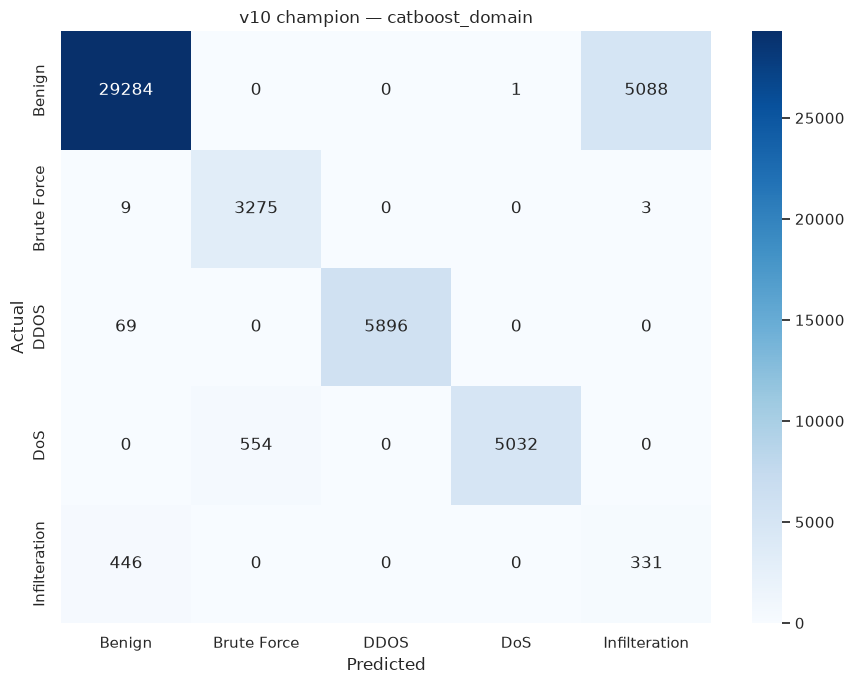

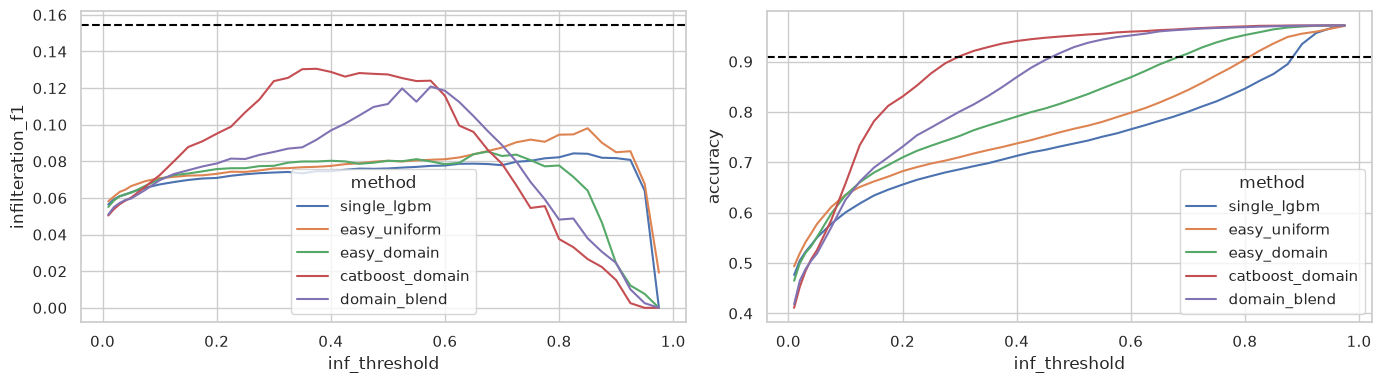

,method,inf_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,worst_day_infilteration_f1,train_seconds
143,catboost_domain,0.375,0.919073,0.748229,0.935845,0.088532,0.248391,0.130538,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1987,0.184248,8.072979
193,domain_blend,0.575,0.918592,0.745808,0.948568,0.093399,0.171171,0.120854,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1291,0.159186,15.684895
78,easy_uniform,0.850,0.917458,0.740113,0.935765,0.067372,0.180180,0.098074,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,1938,0.152174,7.264012
113,easy_domain,0.675,0.916823,0.736921,0.905337,0.051608,0.245817,0.085306,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,3510,0.169476,7.345311
35,single_lgbm,0.825,0.916775,0.736679,0.861307,0.047541,0.373230,0.084339,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5810,0.187946,3.524056


In [9]:
report_path = OUTPUT_DIR / "v10_champion_classification_report.csv"
pd.DataFrame(classification_report(y_valid, selected_prediction, output_dict=True, zero_division=0)).T.to_csv(
    report_path, encoding="utf-8-sig"
)
cm = confusion_matrix(y_valid, selected_prediction, labels=classes)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(title=f"v10 champion — {selected_method}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
cm_path = OUTPUT_DIR / "v10_champion_confusion_matrix.png"
fig.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()

best_by_method = search_df.loc[search_df.groupby("method")["infilteration_f1"].idxmax()].copy()
best_path = OUTPUT_DIR / "v10_best_by_method.csv"
best_by_method.to_csv(best_path, index=False, encoding="utf-8-sig")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=search_df, x="inf_threshold", y="infilteration_f1", hue="method", ax=axes[0])
sns.lineplot(data=search_df, x="inf_threshold", y="accuracy", hue="method", ax=axes[1])
axes[0].axhline(V6_BASELINE["infilteration_f1"], ls="--", color="black")
axes[1].axhline(V6_BASELINE["accuracy"], ls="--", color="black")
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v10_method_tradeoff.png"
fig.savefig(tradeoff_path, dpi=160, bbox_inches="tight")
plt.show()
display(best_by_method.sort_values("infilteration_f1", ascending=False))


## 8. 2018-03-01 날짜 홀드아웃


In [10]:
holdout_train_mask = y_all.isin(["Benign", INFILTRATION_LABEL]) & (train_df["Timestamp"] < pd.Timestamp("2018-03-01"))
holdout_valid_mask = y_all.isin(["Benign", INFILTRATION_LABEL]) & (train_df["Timestamp"] >= pd.Timestamp("2018-03-01")) & (train_df["Timestamp"] < pd.Timestamp("2018-03-02"))
holdout_train_index = train_df.index[holdout_train_mask]
holdout_valid_index = train_df.index[holdout_valid_mask]
holdout_weights, _, _, holdout_domain_auc = learn_domain_weights(
    X_flow, holdout_train_index, seed=RANDOM_STATE + 9000
)
holdout_bundle = fit_method(
    selected_method, X_flow, holdout_train_index, holdout_weights, RANDOM_STATE + 10000
)
holdout_probability = predict_bundle(holdout_bundle, X_flow.loc[holdout_valid_index])
holdout_prediction = (holdout_probability >= selected_threshold).astype(int)
holdout_actual = (y_all.loc[holdout_valid_index] == INFILTRATION_LABEL).astype(int).to_numpy()
hp, hr, hf, _ = precision_recall_fscore_support(holdout_actual, holdout_prediction, labels=[1], average=None, zero_division=0)
holdout_metrics = {
    "holdout_precision": float(hp[0]), "holdout_recall": float(hr[0]), "holdout_f1": float(hf[0]),
    "holdout_accuracy": float(accuracy_score(holdout_actual, holdout_prediction)),
    "holdout_domain_auc": holdout_domain_auc,
    "holdout_train_rows": len(holdout_train_index), "holdout_valid_rows": len(holdout_valid_index),
    "holdout_valid_infilteration": int(holdout_actual.sum()),
}
print("Date holdout:", holdout_metrics)
display(pd.crosstab(pd.Series(holdout_actual, name="actual"), pd.Series(holdout_prediction, name="predicted")))


Date holdout: {'holdout_precision': 0.31305903398926654, 'holdout_recall': 0.22766695576756288, 'holdout_f1': 0.26362038664323373, 'holdout_accuracy': 0.6453874984886955, 'holdout_domain_auc': 0.6647441055704163, 'holdout_train_rows': 141060, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306}


predicted,0,1
actual,,
0,4813,1152
1,1781,525


## 9. 승인 판정과 표준 MLflow parent/child runs


In [11]:
hypothesis_supported = (
    champion_metrics["infilteration_f1"] > V6_BASELINE["infilteration_f1"]
    and champion_metrics["infilteration_recall"] >= 0.45
    and champion_metrics["accuracy"] >= 0.89
    and champion_metrics["benign_to_infilteration_fp"] <= 4000
    and champion_metrics["worst_day_infilteration_f1"] >= 0.10
    and holdout_metrics["holdout_f1"] >= 0.15
)
summary_df = pd.DataFrame([
    {"model": "v6_baseline", **V6_BASELINE},
    {"model": "v10_domain_easyensemble", **champion_metrics},
])
summary_path = OUTPUT_DIR / "v10_champion_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
domain_path = OUTPUT_DIR / "v10_domain_summary.csv"
domain_summary.to_csv(domain_path, encoding="utf-8-sig")

notebook_path = cwd / "code_mlflow_pipeline_v10.ipynb"
code_version = file_sha256(notebook_path) if notebook_path.exists() else "unavailable"
lineage_sample = train_df.iloc[:2000].copy()
lineage_numeric = lineage_sample.select_dtypes(include=[np.number]).columns
lineage_sample[lineage_numeric] = lineage_sample[lineage_numeric].astype(float)

with hypothesis_run(
    run_name="v10_domain_easyensemble_validation",
    hypothesis_id=HYPOTHESIS_ID,
    hypothesis=HYPOTHESIS,
    stage="chronological_validation",
    promotion_status="candidate" if hypothesis_supported else "rejected",
    validation_strategy="within_class_80_20_plus_2018_03_01_holdout",
    notebook=notebook_path.name,
    data_version=TRAIN_TEMPORAL.name,
    feature_schema_version="v5-temporal-2-flow-only",
    code_version=code_version,
    extra_tags={"champion_remains": "v10" if hypothesis_supported else "v6"},
) as parent_run:
    mlflow.log_params({
        "train_sample": TRAIN_SAMPLE, "selected_method": selected_method,
        "infilteration_threshold": selected_threshold, "selection_tier": selection_tier,
        "domain_late_fraction": DOMAIN_LATE_FRACTION, "domain_oof_folds": 3,
        "domain_oof_auc": domain_auc, "ensemble_size": ENSEMBLE_SIZE,
        "benign_to_inf_ratio": BENIGN_TO_INF_RATIO,
        "known_attack_threshold": KNOWN_ATTACK_THRESHOLD,
        "training_data_sha256": file_sha256(TRAIN_TEMPORAL),
    })
    mlflow.log_metrics({
        **{k: float(v) for k, v in champion_metrics.items()},
        **{k: float(v) for k, v in holdout_metrics.items()},
        "domain_oof_auc": domain_auc,
    })
    log_dataframe_input(
        lineage_sample, source=TRAIN_TEMPORAL,
        name="train_temporal_v5_sample", context="training_sample", targets=TARGET,
    )
    for artifact in [search_path, report_path, cm_path, best_path, tradeoff_path, summary_path, domain_path]:
        mlflow.log_artifact(str(artifact))
    mlflow.log_artifact(str(notebook_path), artifact_path="code")
    for method in methods:
        best = search_df[search_df["method"] == method].sort_values(
            ["infilteration_f1", "worst_day_infilteration_f1"], ascending=False
        ).iloc[0]
        with mlflow.start_run(run_name=f"v10_candidate_{method}", nested=True):
            mlflow.set_tags({"hypothesis_id": HYPOTHESIS_ID, "stage": "candidate", "method": method})
            mlflow.log_params({
                "method": method, "threshold": float(best["inf_threshold"]),
                "ensemble_size": ENSEMBLE_SIZE if "easy" in method or "blend" in method else 1,
                "domain_weighted": method in {"easy_domain", "catboost_domain", "domain_blend"},
            })
            metric_keys = [
                "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
                "infilteration_precision", "infilteration_recall", "infilteration_f1",
                "benign_to_infilteration_fp", "worst_day_infilteration_f1",
            ]
            mlflow.log_metrics({key: float(best[key]) for key in metric_keys})
    validation_run_id = parent_run.info.run_id

print("Hypothesis supported:", hypothesis_supported)
print("Validation run:", validation_run_id)
display(summary_df)


🏃 View run v10_candidate_single_lgbm at: http://mlflow:5000/#/experiments/1/runs/c982f15448d84da1be49874ae13ea9ad
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v10_candidate_easy_uniform at: http://mlflow:5000/#/experiments/1/runs/a7203ab06e71441f8de3a749089d8621
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v10_candidate_easy_domain at: http://mlflow:5000/#/experiments/1/runs/56e9086cb76f42dbb9ac17c3d0aa7b24
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v10_candidate_catboost_domain at: http://mlflow:5000/#/experiments/1/runs/97442fc896e043f7bd66261754cbadbe
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v10_candidate_domain_blend at: http://mlflow:5000/#/experiments/1/runs/10dc60a892fc4ce8aef9d4c2ece2b732
🧪 View experiment at: http://mlflow:5000/#/experiments/1
🏃 View run v10_domain_easyensemble_validation at: http://mlflow:5000/#/experiments/1/runs/483c19ee3c4b4de08c21764bd40e8ee8
🧪 View experiment at: http://mlflow:5000/#/experiments/1
Hypothesis supported: False
Validation run: 483c19ee3c4b4de08c21764bd40e8ee8


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_f1,ddos_f1,dos_f1,bruteforce_precision,bruteforce_recall,ddos_precision,ddos_recall,dos_precision,dos_recall,worst_day_infilteration_f1
0,v6_baseline,0.920251,0.754148,0.908938,0.092655,0.459459,0.154212,3496,0.920461,0.994183,0.947735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,v10_domain_easyensemble,0.917892,0.742293,0.876570,0.061048,0.425997,0.106791,5088,0.920461,0.994183,0.947735,0.855315,0.996349,1.0,0.988433,0.999801,0.900823,0.20363


## 10. 승인 시 전체 표본 재학습과 Registry 승격


In [12]:
class V10HierarchicalModel(mlflow.pyfunc.PythonModel):
    def __init__(self, gate, subtype, residual_bundle, router_columns, flow_columns, attack_threshold, inf_threshold):
        self.gate = gate
        self.subtype = subtype
        self.residual_bundle = residual_bundle
        self.router_columns = list(router_columns)
        self.flow_columns = list(flow_columns)
        self.attack_threshold = float(attack_threshold)
        self.inf_threshold = float(inf_threshold)

    def predict(self, context, model_input, params=None):
        router = model_input.loc[:, self.router_columns].copy()
        for column in CAT_FEATURES:
            router[column] = router[column].astype("string")
        flow = router.loc[:, self.flow_columns].copy()
        gate_probability = self.gate.predict_proba(router)[:, 1]
        subtype = self.subtype.predict(router)
        accept = np.isin(subtype, KNOWN_ATTACKS) & (gate_probability >= self.attack_threshold)
        inf_probability = predict_bundle(self.residual_bundle, flow)
        residual = np.where(inf_probability >= self.inf_threshold, INFILTRATION_LABEL, "Benign")
        labels = np.where(accept, subtype, residual)
        return pd.DataFrame({TARGET: labels}, index=router.index)

final_run_id = None
registry_version = None
submission_path = None
if hypothesis_supported:
    final_gate = clone(attack_gate)
    final_subtype = clone(attack_subtype)
    final_gate.fit(X_router, y_attack_binary)
    final_subtype.fit(X_router.loc[y_all != "Benign"], y_all.loc[y_all != "Benign"])
    all_residual_index = train_df.index[y_all.isin(["Benign", INFILTRATION_LABEL])]
    final_weights, _, _, final_domain_auc = learn_domain_weights(X_flow, all_residual_index, seed=RANDOM_STATE + 20000)
    final_bundle = fit_method(selected_method, X_flow, all_residual_index, final_weights, RANDOM_STATE + 21000)
    composite = V10HierarchicalModel(
        final_gate, final_subtype, final_bundle, X_router.columns, X_flow.columns,
        KNOWN_ATTACK_THRESHOLD, selected_threshold,
    )
    input_example = X_router.iloc[:5].copy()
    output_example = composite.predict(None, input_example)
    from mlflow.models import infer_signature
    signature = infer_signature(input_example, output_example)
    with hypothesis_run(
        run_name="v10_domain_easyensemble_refit",
        hypothesis_id=HYPOTHESIS_ID, hypothesis=HYPOTHESIS, stage="refit",
        promotion_status="champion", validation_strategy="approved_v10_validation",
        notebook="code_mlflow_pipeline_v10.ipynb", data_version=TRAIN_TEMPORAL.name,
        feature_schema_version="v5-temporal-2-router-plus-flow",
        code_version=file_sha256(cwd / "code_mlflow_pipeline_v10.ipynb"),
        extra_tags={"source_validation_run_id": validation_run_id},
    ) as final_run:
        mlflow.log_params({
            "selected_method": selected_method, "attack_threshold": KNOWN_ATTACK_THRESHOLD,
            "infilteration_threshold": selected_threshold, "source_validation_run_id": validation_run_id,
            "final_domain_auc": final_domain_auc,
        })
        mlflow.log_metrics({k: float(v) for k, v in champion_metrics.items()})
        model_info = mlflow.pyfunc.log_model(
            name="network_classifier", python_model=composite,
            input_example=input_example, signature=signature,
            code_paths=[str(PROJECT_DIR / "src" / "mlflow_workflow.py")],
        )
        version = register_model_version(
            model_uri=model_info.model_uri,
            version_tags={
                "validation_status": "passed", "hypothesis_id": HYPOTHESIS_ID,
                "source_validation_run_id": validation_run_id,
            },
            registered_model_tags={"project": "network-classification", "task": "multiclass-classification"},
        )
        final_run_id = final_run.info.run_id
        registry_version = version.version
    with duckdb.connect() as con:
        test_df = con.execute(f"SELECT * FROM {parquet_expr(TEST_TEMPORAL)}").df()
    test_df = add_ids_features(test_df)
    test_ids = test_df[ID_COL].copy()
    X_test_router = test_df.drop(
        columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore"
    )
    for column in CAT_FEATURES:
        X_test_router[column] = X_test_router[column].astype("string")
    X_test_router = X_test_router.loc[:, X_router.columns]
    test_prediction = composite.predict(None, X_test_router)[TARGET].to_numpy()
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_prediction}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v10.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    print("Submission:", submission_path, submission.shape)
else:
    rejection_path = OUTPUT_DIR / "REJECTED.md"
    rejection_path.write_text(
        "# v10 experiment status: rejected\n\n"
        "v6 remains the Registry champion.\n\n"
        f"- Selected method: {selected_method}, threshold: {selected_threshold}\n"
        f"- Infilteration precision / recall / F1: {champion_metrics['infilteration_precision']:.6f} / {champion_metrics['infilteration_recall']:.6f} / {champion_metrics['infilteration_f1']:.6f}\n"
        f"- Accuracy: {champion_metrics['accuracy']:.6f}; false positives: {int(champion_metrics['benign_to_infilteration_fp'])}\n"
        f"- Worst-day F1: {champion_metrics['worst_day_infilteration_f1']:.6f}\n"
        f"- Date holdout F1 / accuracy: {holdout_metrics['holdout_f1']:.6f} / {holdout_metrics['holdout_accuracy']:.6f}\n"
        f"- Validation run: `{validation_run_id}`\n",
        encoding="utf-8",
    )
    print("Rejected:", rejection_path)

print("Final run:", final_run_id)
print("Registry version:", registry_version)
print("Champion alias remains:", "v10" if hypothesis_supported else "v6")


Rejected: /home/jovyan/work/network-classification/outputs/v10/REJECTED.md
Final run: None
Registry version: None
Champion alias remains: v6


/opt/conda/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
